# <center>Sci‑Fi Movie Recommendation System for "Cold-Start" Users: Collaborative Filtering vs. Matrix Factorization</center>

# Part 3: SVD & NMF Modeling

This notebook builds on the data prepared in `01_data_prep.ipynb` (Sci-Fi ratings, active/cold-start data split) and the KNN baseline established in `02_knn_modeling.ipynb`. It addresses Business Question 1 (does model choice materially affect recommendation quality?) by comparing memory-based KNN against model-based matrix factorization (SVD and NMF), and Business Question 2 (precision@k/recall@k) using the full ranking-based formulation, made possible here by SVD/NMF's ability to predict ratings across many candidate movies per user, unlike the single-target-movie KNN pipeline. See `01_data_prep.ipynb`, `02_knn_modeling.ipynb`, or the **README** for full business context.

Unlike KNN, which relies on a heavily imputed user-movie matrix (as demonstrated in the previous notebook), SVD and NMF train directly on observed ratings only, avoiding the imputation-driven signal dilution identified as a key limitation of the memory-based approach.

In [1]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from surprise import Dataset, Reader, SVD, NMF
from surprise import NormalPredictor, BaselineOnly
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise.model_selection import GridSearchCV, cross_validate, KFold
from surprise import accuracy

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity

from collections import defaultdict
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

### Loading the Data

In [2]:
# Load the active-user and cold-start datasets prepared in 01_data_prep.ipynb
df_active = pd.read_parquet('ml-32m/df_active.parquet')
df_active.head()

,userId,movieId,rating,title,genres,_merge
1361,15,208,0.5,Waterworld (1995),Action|Adventure|Sci-Fi,both
1369,15,780,2.0,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,both
1374,15,1270,3.5,Back to the Future (1985),Adventure|Comedy|Sci-Fi,both
1377,15,1527,4.0,"Fifth Element, The (1997)",Action|Adventure|Comedy|Sci-Fi,both
1407,15,5349,3.0,Spider-Man (2002),Action|Adventure|Sci-Fi|Thriller,both


In [3]:
df_cold_start = pd.read_parquet('ml-32m/df_cold_start.parquet')
df_cold_start.head()

,userId,movieId,rating,title,genres,_merge
408,6,2529,3.5,Planet of the Apes (1968),Action|Drama|Sci-Fi,both
410,6,2628,5.0,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,both
411,6,2640,1.0,Superman (1978),Action|Adventure|Sci-Fi,both
417,6,3697,5.0,Predator 2 (1990),Action|Sci-Fi|Thriller,both
424,6,5445,5.0,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,both


### Movie Popularity vs. User Activity
Before modeling, it will be useful to examine how interactions are distributed across movies and users. Large-scale rating datasets commonly show a heavy-tailed pattern: a small number of popular movies account for a disproportionate share of ratings, while most movies sit in a long tail of sparse activity. The complementary cumulative distribution function (CCDF), P(Degree ≥ d), is used to check whether this dataset follows the same pattern, and whether the user side behaves like the movie side.

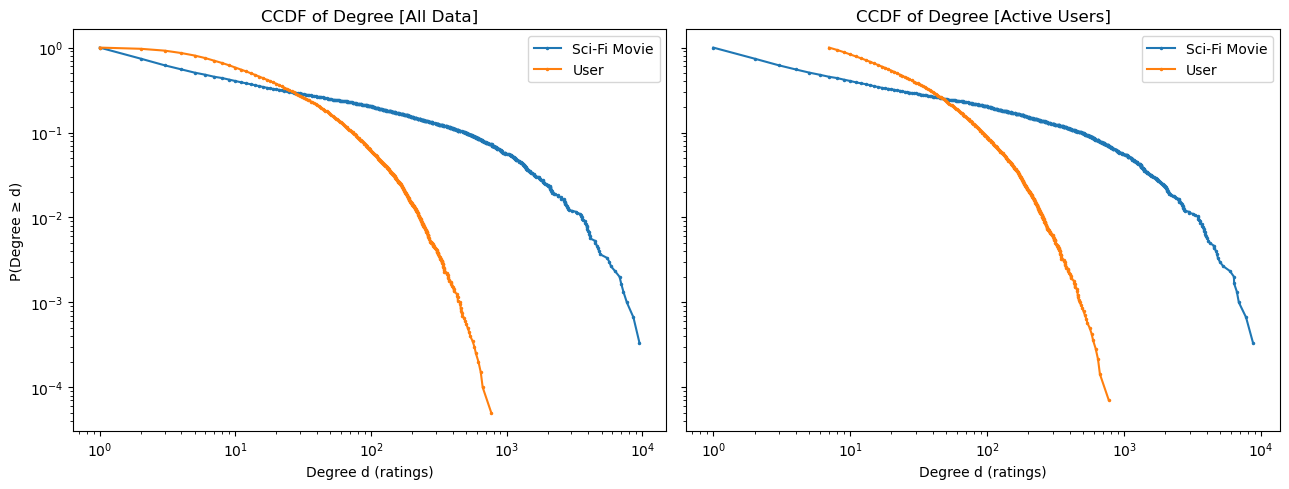

In [4]:
def ccdf(degrees): 
    """Return (d, P(Degree >= d)) for each distinct degree value d."""
    vals, counts = np.unique(degrees.values, return_counts=True)
    p_ge = counts[::-1].cumsum()[::-1] / counts.sum()
    return vals, p_ge

df_all = pd.read_parquet('ml-32m/df_scifi_movies_reduced.parquet')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (df, title) in zip(axes, [(df_all, 'All Data'), (df_active, 'Active Users')]):
    for col, label, color in [('movieId', 'Sci-Fi Movie', 'tab:blue'),
                              ('userId', 'User', 'tab:orange')]:
        x, y = ccdf(df[col].value_counts())
        ax.plot(x, y, marker='.', linestyle='-', markersize=3, label=label, color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree d (ratings)')
    ax.set_title(f'CCDF of Degree [{title}]')
    ax.legend()
axes[0].set_ylabel('P(Degree ≥ d)')
plt.tight_layout()
plt.show()

**Key Insights**  
- Movie degree is heavy-tailed: a small set of blockbusters receives thousands of ratings, while a large minority of movies have only 1-2 ratings.
- User degree has a thinner tail with a cutoff around a few hundred ratings, so the user-activity distribution is less extreme than the movie one.
- The active-user filter removes users with fewer than 7 ratings (the right panel's user curve starts at ~7 rather than 1), and leaves the movie distribution almost unchanged.
- The heavy tail is evidence of concentration and sparsity, not a formal power-law fit.

Mean: 3.481 | Median: 3.5 | Std: 1.086
Scale midpoint (0.5-5.0): 2.75
Std of user mean ratings (users with >= 20 ratings): 0.549  (n=7,482)
Std of movie mean ratings (movies with >= 20 ratings): 0.519  (n=968)


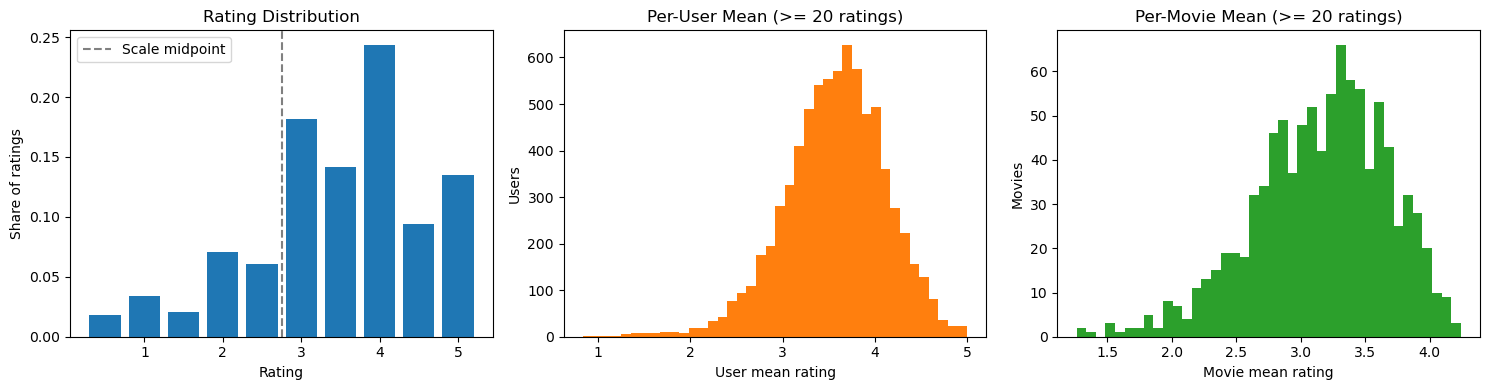

In [5]:
ratings = df_active['rating']
print(f"Mean: {ratings.mean():.3f} | Median: {ratings.median():.1f} | Std: {ratings.std():.3f}")
print(f"Scale midpoint (0.5-5.0): 2.75")

# Per-user and per-movie mean ratings; restrict to >= 20 ratings so the means aren't dominated by noise
MIN_N = 20
user_stats = df_active.groupby('userId')['rating'].agg(['mean', 'count'])
item_stats = df_active.groupby('movieId')['rating'].agg(['mean', 'count'])
user_mean = user_stats.loc[user_stats['count'] >= MIN_N, 'mean']
item_mean = item_stats.loc[item_stats['count'] >= MIN_N, 'mean']

print(f"Std of user mean ratings (users with >= {MIN_N} ratings): {user_mean.std():.3f}  (n={len(user_mean):,})")
print(f"Std of movie mean ratings (movies with >= {MIN_N} ratings): {item_mean.std():.3f}  (n={len(item_mean):,})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = ratings.value_counts(normalize=True).sort_index()
axes[0].bar(counts.index, counts.values, width=0.4, color='tab:blue')
axes[0].axvline(2.75, color='gray', linestyle='--', label='Scale midpoint')
axes[0].set(xlabel='Rating', ylabel='Share of ratings', title='Rating Distribution')
axes[0].legend()

axes[1].hist(user_mean, bins=40, color='tab:orange')
axes[1].set(xlabel='User mean rating', ylabel='Users', title=f'Per-User Mean (>= {MIN_N} ratings)')

axes[2].hist(item_mean, bins=40, color='tab:green')
axes[2].set(xlabel='Movie mean rating', ylabel='Movies', title=f'Per-Movie Mean (>= {MIN_N} ratings)')

plt.tight_layout()
plt.show()

**Key Insights**  
- The mean rating is 3.48 (median 3.5), well above the scale midpoint of 2.75, and the distribution is skewed toward higher ratings, with 4.0 the most common value.
- Since ratings are only observed for movies users chose to watch, this likely reflects both generous rating habits and selection toward movies users expect to enjoy. The data cannot separate the two.
- The standard deviation of user mean ratings is 0.549 (users with ≥ 20 ratings) and of movie mean ratings 0.519 (movies with ≥ 20 ratings). Both are about half a rating point, so users and movies differ substantially in their typical ratings. This is what the bias terms in the baseline ($\mu + b_u + b_i$) can capture, before any latent factors are added.
- These spreads include some sampling noise, since each mean comes from a limited number of ratings, so the true spread is somewhat smaller. The ≥ 20 filter keeps that noise modest. It also means these figures describe only 7,482 users and 968 movies, not the full dataset.

## Preparing Data for Surprise  
- Unlike the KNN pipeline, which required a pivoted user-movie matrix with imputation, `surprise` operates directly on raw (user, item, rating) triples. No pivoting, imputation, or centering is needed here
- This is one of the key structural advantages of model-based collaborative filtering over memory-based approaches.
- A three-way 60% / 20% / 20% split is used instead of the usual train/test split.
> - Validation (20%) drives every modeling decision: hyperparameter tuning, model comparison, and the generalization-gap check.
> - Test (20%) is touched once, after all decisions are frozen, so the final SVD/NMF numbers are not optimistically biased by model selection.
> - The split is random over ratings, not over users. This matches the task: predict held-out ratings for users the model already knows.
> - Truly new users are handled separately in the cold-start analysis.
> - Splitting over ratings (rather than users) means every active user almost always keeps some training ratings, so the evaluation is not dominated by unseen users.

In [6]:
cols = ['userId', 'movieId', 'rating']
reader = Reader(rating_scale=(0.5, 5.0))

# 60% train / 20% validation / 20% test, split over ratings
df_trainval, df_test = train_test_split(df_active[cols], test_size=0.20, random_state=72)
df_train, df_val = train_test_split(df_trainval, test_size=0.25, random_state=72)  # 0.25 * 0.8 = 0.20

data_train = Dataset.load_from_df(df_train, reader)    
trainset = data_train.build_full_trainset()
valset = list(df_val.itertuples(index=False, name=None)) 
testset = list(df_test.itertuples(index=False, name=None)) # for the final evaluation

print(f"Train: {trainset.n_users} users, {trainset.n_items} movies, {trainset.n_ratings} ratings")
print(f"Validation: {len(valset)} ratings | Test: {len(testset)} ratings")

# How many held-out ratings involve a user or movie never seen in training?
train_users, train_items = set(df_train['userId']), set(df_train['movieId'])
for name, d in [('Validation', df_val), ('Test', df_test)]:
    cold_item = (~d['movieId'].isin(train_items)).mean()
    cold_user = (~d['userId'].isin(train_users)).mean()
    print(f"{name}: {cold_item:.2%} of ratings on unseen movies, {cold_user:.2%} on unseen users")

Train: 14007 users, 2600 movies, 336309 ratings
Validation: 112104 ratings | Test: 112104 ratings
Validation: 0.23% of ratings on unseen movies, 0.00% on unseen users
Test: 0.23% of ratings on unseen movies, 0.01% on unseen users


**Key Insights**

**Why three splits**
- **Train (60%)** fits model parameters and runs cross-validation for hyperparameter tuning.
- **Validation (20%)** drives every decision: `n_factors`, regularization, the train/validation gap, and precision@k/recall@k comparisons.
- **Test (20%)** is held out and used once, after all modeling decisions are fixed, so the final SVD/NMF numbers aren't optimistically biased by model selection.
- The split is over **ratings, not users**. The task is predicting held-out ratings for users the model already knows; new users are handled separately in the cold-start analysis.

**What the split produced**
- 336,309 + 112,104 + 112,104 = 560,517 ratings — matches the active-user dataset exactly, so no ratings were lost or duplicated.
- Training covers 14,007 of 14,009 active users. Only ~400 movies (13%) appear solely in validation or test, and they account for a tiny share of held-out ratings.
- Validation and test sets are the same size (112,104) with nearly identical cold-start profiles, so validation error is a fair proxy for test error.

**Cold-start exposure**
- Only 0.23% of validation and 0.23% of test ratings involve a movie unseen in training (≈260 each). Unseen users are negligible (0.00% / 0.01%).
- Surprise predicts the global mean for unseen users or movies. At this share the effect on RMSE is small and does not change any model comparison.
- Average training density is ~24 ratings per user (336,309 ÷ 14,007). Reserving data for validation lowers density versus an 80/20 split — one reason to refit the chosen models on train+validation before the final test evaluation.

## Baseline Model
Before fitting the full SVD model, a baseline is established using only global, user, and item bias terms (no latent factors). This mirrors the staged approach in Salako (2026): $\hat{r}_{ui} = \mu + b_u + b_i$, where $\mu$ is the global mean rating, $b_u$ is a user's tendency to rate above or below average, and $b_i$ is an item's tendency to be rated above or below average. Comparing the full SVD model against this baseline shows how much predictive value comes specifically from modeling latent user-item interactions, rather than from simpler rating tendencies alone.

In [7]:
# Bias-only baseline: predicts using global mean, user bias, and item bias, no latent factors
baseline = BaselineOnly()
baseline.fit(trainset)
baseline_predictions = baseline.test(valset)

baseline_rmse = accuracy.rmse(baseline_predictions, verbose=False)
baseline_mae = accuracy.mae(baseline_predictions, verbose=False)

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")

Estimating biases using als...
Baseline RMSE: 0.8711
Baseline MAE: 0.6688


**Key Insights**  
- The bias-only baseline reaches RMSE 0.8711 and MAE 0.6688 on validation, using just $μ + b_u + b_i$ — no latent factors.
- This is close to the KNN model from the previous notebook, which suggests a large share of KNN's apparent predictive power came from the same general user/item rating tendencies rather than genuine neighbor-based signal. It also echoes the KNN notebook's centering experiment, where removing that level-matching shortcut sharply worsened KNN's performance.
- The baseline establishes the floor that SVD and NMF must beat to justify their added complexity. Any gain beyond ~0.87 RMSE is what the latent factors are actually contributing.

# <center> Singular Value Decomposition (SVD) Model </center>
The full SVD model extends the bias-only baseline by adding latent factor vectors for each user and item, capturing personalized taste rather than just general rating tendencies (Koren, Bell & Volinsky, 2009). This is fit here with `surprise`'s default hyperparameters as an initial comparison point against the baseline, before any tuning.

## SVD Prediction Formula

$$
\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u^T \mathbf{q}_i
$$

**Where:**

- $\hat{r}_{ui}$ — the predicted rating that user $u$ would give to item $i$.
- $\mu$ — the global mean rating across all observed ratings in the training set.
- $b_u$ — the user bias: how much user $u$ tends to rate above or below the global mean (e.g., a generous rater has $b_u > 0$).
- $b_i$ — the item bias: how much item $i$ tends to be rated above or below the global mean (e.g., a universally loved movie has $b_i > 0$).
- $\mathbf{p}_u$ — the latent factor vector for user $u$ (length $k$, where $k$ = `n_factors`). Captures the user's taste profile across $k$ hidden dimensions.
- $\mathbf{q}_i$ — the latent factor vector for item $i$ (length $k$). Captures the item's characteristics across the same $k$ dimensions.
- $\mathbf{p}_u^T \mathbf{q}_i$ — the dot product of the user and item factor vectors: the personalized interaction term. Large positive value = user's taste aligns with this item's characteristics; large negative value = user's taste runs against this item.

**Contrast with NMF:** The formula is identical to NMF's, but SVD places **no constraint** on the sign of the factor entries — $\mathbf{p}_u$ and $\mathbf{q}_i$ can contain both positive and negative values. This means each latent dimension can encode both "liking" and "disliking" directions, giving SVD strictly more expressive freedom than NMF. The trade-off: SVD factors are harder to interpret as additive "topics," but the model can capture taste patterns that NMF's non-negativity constraint rules out.

**Note on implementation:** Surprise's `SVD` is not classical truncated SVD. It is **FunkSVD** — a stochastic gradient descent method that learns $\mu$, $b_u$, $b_i$, $\mathbf{p}_u$, and $\mathbf{q}_i$ jointly by minimizing regularized squared error on *observed ratings only* (i.e., no matrix imputation is needed). This is what allows it to handle the sparse rating matrix directly.

In [8]:
# Fit SVD with default hyperparameters
svd_default = SVD(random_state=72)
svd_default.fit(trainset)
svd_default_predictions = svd_default.test(valset)

svd_default_rmse = accuracy.rmse(svd_default_predictions, verbose=False)
svd_default_mae = accuracy.mae(svd_default_predictions, verbose=False)

print(f"SVD (default) RMSE: {svd_default_rmse:.4f}")
print(f"SVD (default) MAE: {svd_default_mae:.4f}")

SVD (default) RMSE: 0.8449
SVD (default) MAE: 0.6462


In [9]:
# Compare baseline vs. default SVD
comparison = pd.DataFrame({
    'Model': ['Bias-only Baseline', 'SVD (default)'],
    'RMSE': [baseline_rmse, svd_default_rmse],
    'MAE': [baseline_mae, svd_default_mae]
})
print(comparison)

                Model      RMSE       MAE
0  Bias-only Baseline  0.871068  0.668809
1       SVD (default)  0.844876  0.646205


**Key Insight**

SVD with default parameters (RMSE = 0.8449, MAE = 0.6462) modestly outperforms the bias-only baseline (RMSE = 0.8711, MAE = 0.6688), a roughly 3% reduction in RMSE. This confirms that latent factors capture some genuine signal beyond simple user/item rating tendencies, though the improvement is moderate rather than dramatic, consistent with the sparsity challenges already identified in this dataset. Hyperparameter tuning (latent factor count, regularization) may further improve this gap.

### Truncated SVD on a bias-removed matrix  

Before moving into hyperparameter tuning, compute the singular values of the bias-removed user-item residual matrix. Then we plot them against a shuffled noise reference, to see whether the residual spectrum is distinguishable from noise and, if so, over how many components.

**Caution**   
- This is **classical SVD**, not FunkSVD: `scipy.sparse.linalg.svds` applied to a bias-removed matrix with zeros treated as "no interaction" — a truncated SVD of a sparse matrix.
- This cell uses scipy.sparse.linalg.svds on a fully-observed-after-bias-removal matrix with zeros treated as "no interaction" — a truncated SVD of a sparse matrix.
- Surprise's SVD is a completely different algorithm: SGD-based FunkSVD trained only on observed ratings, with no zero-filling, and with jointly-fit, regularized biases and latent factors. So the scree plot here is only suggestive of the data's intrinsic dimensionality; it does not tell what n_factors Surprise's SVD will find optimal, because the two methods decompose different objects under different objectives (Frobenius reconstruction vs. regularized rating prediction).
- However, it is reported here as a practically useful heuristic.

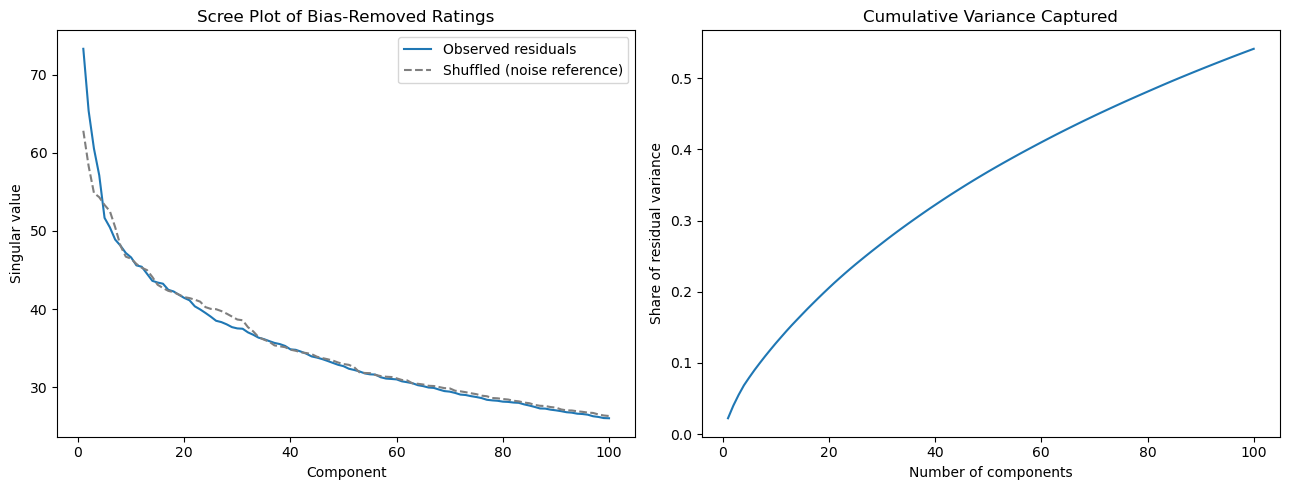

In [10]:
# Bias-removed residuals from training ratings only
# Uses the already-fitted BaselineOnly model so residuals are the true
# r_ui - (mu + b_u + b_i), not a sequential mean-removal approximation.
u, i, r = zip(*trainset.all_ratings())
res_df = pd.DataFrame({'u': u, 'i': i, 'r': r})

bu = np.array([baseline.bu[u] for u in range(trainset.n_users)])
bi = np.array([baseline.bi[i] for i in range(trainset.n_items)])
res_df['pred'] = baseline.trainset.global_mean + bu[res_df['u'].values] + bi[res_df['i'].values]
res_df['res'] = res_df['r'] - res_df['pred']

def top_singular_values(residuals, k=100):
    M = csr_matrix((residuals, (res_df['u'].values, res_df['i'].values)),
                   shape=(trainset.n_users, trainset.n_items))
    s = np.sort(svds(M, k=k, return_singular_vectors=False))[::-1]
    return s, M.power(2).sum()          # total energy for the variance share

k_max = 100
s_real, total_energy = top_singular_values(res_df['res'].values, k_max)

# Noise reference: same sparsity pattern, residual values shuffled
rng = np.random.default_rng(72)
s_null, _ = top_singular_values(rng.permutation(res_df['res'].values), k_max) 

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(range(1, k_max + 1), s_real, label='Observed residuals', color='tab:blue')
ax[0].plot(range(1, k_max + 1), s_null, label='Shuffled (noise reference)', color='tab:gray', linestyle='--')
ax[0].set_xlabel('Component')
ax[0].set_ylabel('Singular value')
ax[0].set_title('Scree Plot of Bias-Removed Ratings')
ax[0].legend()

ax[1].plot(range(1, k_max + 1), np.cumsum(s_real**2) / total_energy, color='tab:blue')
ax[1].set_xlabel('Number of components')
ax[1].set_ylabel('Share of residual variance')
ax[1].set_title('Cumulative Variance Captured')

plt.tight_layout()
plt.show()

In [11]:
print(f"Residual mean:              {res_df['res'].mean():.4f}")
print(f"Mean |per-user residual|:   {res_df.groupby('u')['res'].mean().abs().mean():.4f}")
print(f"Mean |per-item residual|:   {res_df.groupby('i')['res'].mean().abs().mean():.4f}")

print(f"bu: mean={baseline.bu.mean():.4f}, std={baseline.bu.std():.4f}")
print(f"bi: mean={baseline.bi.mean():.4f}, std={baseline.bi.std():.4f}")

Residual mean:              -0.0085
Mean |per-user residual|:   0.2333
Mean |per-item residual|:   0.4303
bu: mean=-0.0137, std=0.2835
bi: mean=-0.1180, std=0.2957


**Key Insights**
- The bias-removed residual spectrum is **nearly indistinguishable from the shuffled noise reference across all 100 components**. The blue curve overlaps the gray curve for the first ~20–30 components, then sits slightly *below* it at higher components — a common finite-sample artifact of comparing a structured matrix to a permutation null.
- This says the residual matrix contains **almost no latent structure beyond the bias terms**. What variance remains after removing $μ + b_u + b_i$ behaves like noise.
- The cumulative-variance curve confirms this: the top 10 components explain only ~10% of residual variance, and the curve has no elbow. Structure, if any, is weak and diffuse.
- These plots are directional evidence that the data does not support a high-dimensional latent space. The grid search and train/validation gap check in the following cells provide more precise evidence for the final `n_factors` choice.
- Together with the marginal RMSE improvement of SVD over the bias-only baseline (~3%), this suggests that most of the predictable signal in this dataset is captured by user and item biases, with latent factors adding little on top.

## Hyperparameter Tuning
Following Salako (2026), an exhaustive grid search is conducted over the number of latent factors, regularization strength, learning rate, and training epochs to identify a configuration that balances model capacity against overfitting risk, given the sparsity of this dataset.

**Parameter Choices**

- **`n_factors` (10, 20, 50, 100, 150, 200)**: controls the number of *latent dimensions* used to represent each user and movie. Following the pattern observed in Salako (2026), where `k=100` led to severe overfitting on the full MovieLens 32M dataset (Training RMSE dropped to 0.42 while Test RMSE rose above 1.0), this range spans from a low-capacity model (10) to a high-capacity one (200), allowing the same underfitting-versus-overfitting tradeoff to be checked directly against this project's smaller, Sci-Fi-filtered, sample-reduced dataset. The ceiling was raised to 200 after an initial sweep showed the CV minimum was still descending at 100.
- **`reg_all` (0.02, 0.05, 0.1)**: a single *regularization strength* applied to all latent factors and biases, corresponding to $\tau$ in Salako (2026)'s formulation. Higher values penalize large factor magnitudes more heavily, reducing overfitting risk at the cost of model flexibility. `0.02` is `surprise`'s own library default; `0.05` and `0.1` test progressively stronger regularization, following Salako (2026)'s finding that stronger regularization consistently improved performance on sparse data.
- **`lr_all` (0.005, 0.01, 0.02, 0.05, 0.1)**: the *learning rate* for the stochastic gradient descent optimization used to fit the latent factors. `0.005` is `surprise`'s default; the additional values test whether a larger step size still converges reliably within the default number of training epochs, without under- or overshooting the optimum.
- **`n_epochs` (20, 50, 100)**: the number of SGD passes over the training data. `20` is `surprise`'s default; `50` and `100` test whether the factor matrices benefit from longer optimization. This axis was added because the initial grid showed that model performance was still improving at the default 20 epochs, particularly at higher `n_factors`.
- **`cv=3`**: 3-fold *cross-validation* is used within the grid search (rather than a single train/validation holdout) to reduce the risk that one particular fold's sampling noise drives the parameter selection, at a moderate computational cost given this dataset's already-reduced size.
- **`n_jobs=-1`**: parallelizes the grid search across all available CPU cores, since this search fits $6 \times 3 \times 5 \times 3 \times 3 = 810$ separate model fits in total.

In [12]:
# Rebuild a Dataset from the existing training split only
raw_train = [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r)
             for (u, i, r) in trainset.all_ratings()]
# GridSearchCV needs a Dataset (here, a full trainset) to run its own CV folds on with raw IDs.
df_train = pd.DataFrame(raw_train, columns=['userId', 'movieId', 'rating'])
data_train = Dataset.load_from_df(df_train, reader)

In [13]:
param_grid = {
    'n_factors': [10, 20, 50, 100, 150, 200],
    'reg_all': [0.02, 0.05, 0.1],
    'lr_all': [0.005, 0.01, 0.02, 0.05, 0.1], # adjusted based on results
    'n_epochs': [20, 50, 100],
    'random_state': [72]
}
n_folds = 3
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=KFold(n_splits=n_folds, random_state=72), n_jobs=-1)
grid_search.fit(data_train)

print(f"Best RMSE: {grid_search.best_score['rmse']:.4f}")
print(f"Best params (RMSE): {grid_search.best_params['rmse']}")

Best RMSE: 0.8386
Best params (RMSE): {'n_factors': 200, 'reg_all': 0.1, 'lr_all': 0.01, 'n_epochs': 100, 'random_state': 72}


**Key Insight**
- The grid search selects `n_factors=200`, `reg_all=0.1`, `lr_all=0.01`, `n_epochs=100` with a CV RMSE of 0.8386.
- Both `n_factors` (200) and `reg_all` (0.1) sit at grid boundaries, so neither is a located optimum — the true minimum may lie outside the searched range.
- The boundary result motivates the next two cells: a direct `n_factors` sweep to check whether more capacity continues to help, and a bias–variance trade-off check to decide the final factor count.

### Verifying the Selected Model
Before adopting the grid search's top parameters, the selected model is refit on the training set and evaluated on the held-out validation set directly, and its performance on the training data itself is checked for signs of overfitting, following the same scrutiny applied to KNN's hyperparameter selection earlier in this project.

In [14]:
# Refit the best model on the actual trainset, evaluate on the actual validation set
best = grid_search.best_params['rmse']
best_svd = SVD(n_factors=best['n_factors'], reg_all=best['reg_all'], lr_all=best['lr_all'], n_epochs=best['n_epochs'], random_state=72)
best_svd.fit(trainset)

val_predictions = best_svd.test(valset)
train_predictions = best_svd.test(trainset.build_testset()) 

val_rmse = accuracy.rmse(val_predictions, verbose=False)
train_rmse = accuracy.rmse(train_predictions, verbose=False)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {val_rmse:.4f}")
print(f"Gap (Test - Train): {val_rmse - train_rmse:.4f}")

Train RMSE: 0.5659
Test RMSE: 0.8152
Gap (Test - Train): 0.2493


**Key Insight**
- Refitting the grid-search winner (`n_factors=200, reg_all=0.1, lr_all=0.01, n_epochs=100`) on the training split gives Train RMSE 0.5659 vs. Validation RMSE 0.8152, a gap of 0.2493.
- The large gap is the expected overfitting signature at high capacity: with 200 latent factors and only ~24 ratings per user, the model fits training noise that does not generalize.
- Validation RMSE (0.8152) is close to the grid search's CV estimate (0.8386), confirming the CV procedure is not wildly optimistic — but the gap itself is the more informative number for the capacity decision.
- The next cell checks whether a smaller factor count trades a small amount of validation accuracy for a substantially smaller gap.

### Checking a More Conservative Factor Count
Given evidence of overfitting at `n_factors=200`, a smaller factor count is evaluated directly, following Salako (2026)'s finding that models with fewer latent dimensions generalized better despite higher training error, particularly on sparse rating data.

In [15]:
# Compare factor counts against the grid search's selection
factor_counts = [10, 20, 50, 100, 200]
results = []

best = grid_search.best_params['rmse']
print(f"Sweeping n_factors at tuned values: reg_all={best['reg_all']}, lr_all={best['lr_all']}")
for n in factor_counts:
    model = SVD(n_factors=n, reg_all=best['reg_all'], lr_all=best['lr_all'], random_state=72)
    model.fit(trainset)

    val_preds = model.test(valset)
    train_preds = model.test(trainset.build_testset())

    val_rmse = accuracy.rmse(val_preds, verbose=False)
    train_rmse = accuracy.rmse(train_preds, verbose=False)

    results.append({
        'n_factors': n,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'gap': val_rmse - train_rmse
    })
    print(f"n_factors={n} —> Train RMSE: {train_rmse:.4f}, "
          f"Validation RMSE: {val_rmse:.4f}, Gap: {val_rmse - train_rmse:.4f}")

results_df = pd.DataFrame(results)
results_df

Sweeping n_factors at tuned values: reg_all=0.1, lr_all=0.01
n_factors=10 —> Train RMSE: 0.8143, Validation RMSE: 0.8572, Gap: 0.0429
n_factors=20 —> Train RMSE: 0.8079, Validation RMSE: 0.8557, Gap: 0.0478
n_factors=50 —> Train RMSE: 0.7886, Validation RMSE: 0.8498, Gap: 0.0612
n_factors=100 —> Train RMSE: 0.7704, Validation RMSE: 0.8476, Gap: 0.0772
n_factors=200 —> Train RMSE: 0.7420, Validation RMSE: 0.8435, Gap: 0.1016


,n_factors,train_rmse,val_rmse,gap
0,10,0.814308,0.857195,0.042887
1,20,0.807872,0.855666,0.047793
2,50,0.788633,0.849811,0.061178
3,100,0.770373,0.847588,0.077214
4,200,0.741961,0.843533,0.101572


In [16]:
res = pd.DataFrame(grid_search.cv_results)
res = res[res['param_reg_all'] == 0.05]     
res = res[res['param_lr_all'] == 0.02]  
print(res[['param_n_factors', 'mean_test_rmse', 'std_test_rmse']]
        .sort_values('param_n_factors'))

     param_n_factors  mean_test_rmse  std_test_rmse
21                10        0.862091       0.000850
22                10        0.886095       0.001234
23                10        0.897138       0.001768
66                20        0.860378       0.001153
67                20        0.882393       0.000314
68                20        0.889371       0.000398
112               50        0.862682       0.001800
113               50        0.861935       0.001695
111               50        0.857270       0.001591
156              100        0.851271       0.001474
157              100        0.849071       0.001645
158              100        0.847365       0.001588
201              150        0.849536       0.001509
202              150        0.845181       0.001558
203              150        0.843668       0.001590
247              200        0.843020       0.001390
246              200        0.847846       0.001173
248              200        0.842002       0.001450


**Key Insight**
- The grid search selected `n_factors=200` as technically optimal, and the direct `n_factors` sweep confirms it: validation RMSE decreases monotonically from 0.8572 at `n_factors=10` to 0.8435 at `n_factors=200`.
- The improvement is small in absolute terms (~1.4% validation RMSE from 20 to 200; ~2.1% CV RMSE), and the boundary value is not bracketed, so we cannot know whether it would continue improving.
- The generalization gap grows roughly 2× over the same range (0.0478 at `n_factors=20` → 0.1016 at `n_factors=200`), indicating the additional accuracy is being bought with substantially more overfitting.
- We therefore adopt `n_factors=20` as a bias–variance compromise, accepting a ~1.4% validation RMSE penalty in exchange for a much smaller generalization gap.
- Consistent with the diminishing-returns reasoning applied to the KNN model's hyperparameter selection, `n_factors=20` is prioritized for generalizability over a marginal, overfitting-driven accuracy gain. This echoes Salako (2026), where a similarly modest latent dimension (k=10) outperformed higher-capacity models on a much larger version of this same dataset.

## Final SVD Model
The final SVD model uses `n_factors=20`, selected for its favorable generalization trade-off over the grid search's technically-optimal but overfit `n_factors=200` configuration. Here it is fit on the 60% training split (validation stays held out for the ranking evaluation). A separate refit on train+validation is performed in the final test-evaluation cell.

In [17]:
best = grid_search.best_params['rmse']
print(f"Using SVD hyperparameters: {best}")

svd_20 = SVD(n_factors=20,
             reg_all=best['reg_all'],
             lr_all=best['lr_all'],
             n_epochs=best['n_epochs'],  
             random_state=72)
svd_20.fit(trainset)

print(f"SVD (n_factors=20) trained on {trainset.n_users} users, {trainset.n_items} movies, {trainset.n_ratings} ratings")
print(f"Validation RMSE: {accuracy.rmse(svd_20.test(valset), verbose=False):.4f}")

Using SVD hyperparameters: {'n_factors': 200, 'reg_all': 0.1, 'lr_all': 0.01, 'n_epochs': 100, 'random_state': 72}
SVD (n_factors=20) trained on 14007 users, 2600 movies, 336309 ratings
Validation RMSE: 0.8195


**Key Insights for Final SVD Model**
- `svd_20` is fit on the 60% training split: 14,007 users, 2,600 movies, 336,309 ratings.
- Validation RMSE is 0.8195 — the best of any SVD configuration tested so far, confirming that a small factor count with tuned regularization is a strong operating point for this dataset.
- The model uses the grid search's tuned `reg_all=0.1, lr_all=0.01, n_epochs=100`, and only overrides `n_factors` (200 → 20) for the parsimony reasons established in the previous cell.
- Note: the final refit on train+validation (for the test-set evaluation) is done separately.

# <center> Non-negative Matrix Factorization (NMF) Model </center>
- NMF, similar to SVD, handles sparse data well and models observed interactions.
- Unlike SVD, NMF constrains all latent factors to be non-negative (Lee & Seung, 2001).
- NMF was used because it decomposes the sparse user-item rating matrix into interpretable, non-negative latent factors, such as genre or theme preferences, which aligns naturally with how movie taste can be understood in terms of additive components rather than mixed positive-negative signals.

### NMF Prediction Formula

$$
\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u^T \mathbf{q}_i \quad \text{with} \quad \mathbf{p}_u, \mathbf{q}_i \geq 0
$$

**Where:**

- $\hat{r}_{ui}$ — the predicted rating that user $u$ would give to item $i$.
- $\mu$ — the global mean rating across all observed ratings in the training set.
- $b_u$ — the user bias: how much user $u$ tends to rate above or below the global mean (e.g., a generous rater has $b_u > 0$).
- $b_i$ — the item bias: how much item $i$ tends to be rated above or below the global mean (e.g., a universally loved movie has $b_i > 0$).
- $\mathbf{p}_u$ — the latent factor vector for user $u$ (length $k$, where $k$ = `n_factors`). Captures the user's taste profile across $k$ hidden dimensions.
- $\mathbf{q}_i$ — the latent factor vector for item $i$ (length $k$). Captures the item's characteristics across the same $k$ dimensions.
- $\mathbf{p}_u^T \mathbf{q}_i$ — the dot product of the user and item factor vectors: the personalized interaction term. Large positive value = user's taste aligns with this item's characteristics.
- $\mathbf{p}_u, \mathbf{q}_i \geq 0$ — **the NMF constraint**: every entry of every factor vector must be non-negative. 

**Contrast with SVD:** SVD uses the identical formula but without the non-negativity constraint, so its latent dimensions can represent both "liking" and "disliking" directions. NMF's constraint forces each dimension to represent only a positive contribution.

- Following the same staged process used for SVD, NMF is fit next: default parameters first, then hyperparameter tuning, then a generalization check.  

**Note:** although Surprise's NMF supports bias terms, the final model is fit with biased=False for numerical stability (see the hyperparameter-tuning section). In practice this means the bias terms shown above are zero.

In [18]:
# Fit NMF with default hyperparameters (n_factors=15, n_epochs=50, reg_pu=0.06, reg_qi=0.06)
nmf_default = NMF(random_state=72) 
nmf_default.fit(trainset)
nmf_default_predictions = nmf_default.test(valset)

nmf_default_rmse = accuracy.rmse(nmf_default_predictions, verbose=False)
nmf_default_mae = accuracy.mae(nmf_default_predictions, verbose=False)

print(f"NMF (default) RMSE: {nmf_default_rmse:.4f}")
print(f"NMF (default) MAE: {nmf_default_mae:.4f}")

NMF (default) RMSE: 0.8862
NMF (default) MAE: 0.6748


**Key Insight**
- NMF with default parameters (RMSE = 0.8862, MAE = 0.6748) performs slightly *worse* than the bias-only baseline (RMSE = 0.8711, MAE = 0.6688), and notably worse than default SVD (RMSE = 0.8449, MAE = 0.6462) — a roughly 4.9% higher RMSE than SVD.
- This suggests NMF's non-negativity constraint may be limiting its ability to capture the taste patterns in this dataset as effectively as SVD's unconstrained factors, at least at default settings.
- The comparison is not like-for-like: default SVD uses `n_factors=100` vs. NMF's `15`, and default NMF is regularized more strongly (`reg=0.06` vs. SVD's `reg_all=0.02`). Some of the gap reflects these differing defaults rather than the sign constraint alone.
- Hyperparameter tuning (factor count, epochs, regularization) is needed before drawing a final comparison between the two methods.

### Hyperparameter Tuning
As with SVD, a grid search is conducted over NMF's key parameters. Because NMF's non-negativity constraint makes it more sensitive to the number of training epochs and factors than SVD, `n_epochs` is included in this search alongside `n_factors` and regularization.

In [19]:
param_grid_nmf = {
    'n_factors': [10, 20, 50],
    'n_epochs': [50, 100],
    'reg_pu': [0.05, 0.1],
    'reg_qi': [0.05, 0.1],
    'random_state': [72]
}

grid_search_nmf = GridSearchCV(
    NMF, param_grid_nmf, 
    measures=['rmse', 'mae'], 
    cv=KFold(n_splits=n_folds, random_state=72), 
    n_jobs=-1)
grid_search_nmf.fit(data_train)

print(f"Best RMSE: {grid_search_nmf.best_score['rmse']:.4f}")
print(f"Best params (RMSE): {grid_search_nmf.best_params['rmse']}")

Best RMSE: 0.8776
Best params (RMSE): {'n_factors': 50, 'n_epochs': 100, 'reg_pu': 0.1, 'reg_qi': 0.1, 'random_state': 72}


In [20]:
import inspect
print(inspect.signature(NMF.__init__))
nmf_tmp = NMF(n_factors=10, random_state=72).fit(trainset)
print([a for a in ['bu', 'bi', 'pu', 'qi'] if hasattr(nmf_tmp, a)])
print(type(getattr(nmf_tmp, 'pu', None)), np.shape(getattr(nmf_tmp, 'pu', None)))

(self, n_factors=15, n_epochs=50, biased=False, reg_pu=0.06, reg_qi=0.06, reg_bu=0.02, reg_bi=0.02, lr_bu=0.005, lr_bi=0.005, init_low=0, init_high=1, random_state=None, verbose=False)
['bu', 'bi', 'pu', 'qi']
<class 'numpy.ndarray'> (14007, 10)


**Key Insight**
- The grid search selects `n_factors=50`, `n_epochs=100`, `reg_pu=0.1`, `reg_qi=0.1` with a CV RMSE of 0.8776.
- Both regularization values sit at the grid ceiling (0.1), and `n_epochs` at its ceiling (100) — the same boundary pattern seen with SVD, suggesting the true optima may lie outside the searched range.
- `biased` is fixed at the `NMF` default (`False`), so NMF fits no bias terms — consistent with the diagnostic below showing `bu`/`bi` absent, and with the numerical-stability decision discussed earlier.
- Tuning alone does not close the gap with SVD (CV RMSE 0.8776 vs. SVD's 0.8386), reinforcing that NMF's non-negativity constraint is structurally limiting on this dataset.

**One-Standard-Error Rule Helper**  
- The best params are at the boundaries. We need to know if more would be better. This helper can find it.
- 1-SE Rule Helper defines a function implementing the 1-SE rule — a standard model-selection heuristic: among configurations whose CV error is within one standard error of the best, prefer the most parsimonious (here, smallest n_factors).
- The idea is that configurations within one standard error of the best should be broken by simplicity, not by chasing the raw minimum.
- Note: A strict reading of the 1-SE rule selects among all configurations evaluated by the grid search, not just those matching the winning hyperparameters. Here it is applied conditionally: the other hyperparameters are held at their grid-search winners, and the rule is used only to select n_factors. This is a pragmatic simplification; we are deciding the factor count given the tuned regularization and learning rate, not re-searching the entire space.

In [21]:
def one_se_choice(grid, vary='param_n_factors', fixed_keys=None):
    res = pd.DataFrame(grid.cv_results)
    best_params = grid.best_params['rmse']
    prefix = 'param_'

    if fixed_keys is None:
        fixed_keys = [f'{prefix}{k}' for k in best_params
                      if f'{prefix}{k}' != vary
                      and res[f'{prefix}{k}'].nunique() > 1]   # skip constant columns

    # vectorized filter: build a boolean mask once instead of chained .loc
    mask = np.ones(len(res), dtype=bool)
    for col in fixed_keys:
        mask &= (res[col].values == best_params[col[len(prefix):]])
    res = res.loc[mask]

    if res.empty:
        raise ValueError(
            f"No rows match fixed values {fixed_keys}. "
            f"Grid's best_params are {best_params}."
        )

    res = res.sort_values(vary)
    best_idx = res['mean_test_rmse'].idxmin()
    thr = res.loc[best_idx, 'mean_test_rmse'] \
        + res.loc[best_idx, 'std_test_rmse'] / np.sqrt(n_folds)

    print(res[[vary, 'mean_test_rmse', 'std_test_rmse']].to_string(index=False))
    print(f"Threshold: {thr:.4f}")

    within = res[res['mean_test_rmse'] <= thr].iloc[0]
    return int(within[vary])
print(">> Completed")

>> Completed


### Boundary Probe: Extended `n_factors` Sweeps (SVD & NMF)

In [22]:
svd_wide = GridSearchCV(SVD, {'n_factors': [10, 20, 50, 100, 150, 200], 'reg_all': [0.05],
                              'lr_all': [0.02], 'biased': [True], 'random_state': [72]},
                        measures=['rmse'], cv=n_folds, n_jobs=-1)
svd_wide.fit(data_train)

nmf_wide = GridSearchCV(
    NMF,
    {'n_factors': [10, 20, 50],              # cap at what NMF can handle
     'n_epochs': [100],
     'reg_pu': [0.1], 'reg_qi': [0.1],       # tuned values from grid_search_nmf
     'random_state': [72]},
    measures=['rmse'], cv=n_folds, n_jobs=-1)
nmf_wide.fit(data_train)

# Tolerance sensitivity check
def parsimony_choice(grid, tol):
    res = pd.DataFrame(grid.cv_results)
    best = res['mean_test_rmse'].min()
    return int(res[res['mean_test_rmse'] <= best + tol]['param_n_factors'].min())

for tol in [0.002, 0.005, 0.01]:
    print(f"tol={tol}: SVD -> {parsimony_choice(svd_wide, tol)}, NMF -> {parsimony_choice(nmf_wide, tol)}")

tol=0.002: SVD -> 150, NMF -> 50
tol=0.005: SVD -> 100, NMF -> 50
tol=0.01: SVD -> 50, NMF -> 20


**Key Insight**  
- **Note:** The factor-count decision is tolerance-dependent and therefore must be argued on other grounds (e.g., train/test-gap check, the scree plot).
- The tolerance sensitivity check shows the CV-optimal `n_factors` is **not robust**: SVD's choice swings from 150 to 50 as the tolerance moves from 0.002 to 0.01, and NMF's from 50 to 20.
- NMF's sweep is capped at 50 because the multiplicative update rule diverges beyond that point on this data — a structural limitation, not a tuning choice.
- Because CV alone cannot settle the factor count, the final decision is deferred to the train/validation gap check (next cells).

### Cross-Validated RMSE vs. Latent Factors

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Baseline CV RMSE: 0.8815


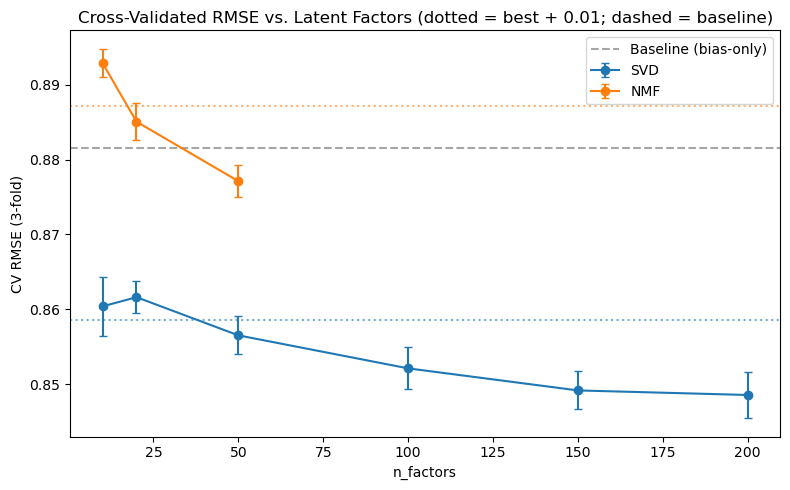

In [23]:
# Bias-only baseline CV RMSE
baseline_cv = cross_validate(BaselineOnly(), data_train, measures=['rmse'],
                             cv=KFold(n_splits=n_folds, random_state=72), verbose=False)
baseline_rmse_cv = baseline_cv['test_rmse'].mean()
print(f"Baseline CV RMSE: {baseline_rmse_cv:.4f}")

svd_res = pd.DataFrame(svd_wide.cv_results).sort_values('param_n_factors')
nmf_res = pd.DataFrame(nmf_wide.cv_results).sort_values('param_n_factors')

fig, ax = plt.subplots(figsize=(8, 5))
for res, name, color in [(svd_res, 'SVD', 'tab:blue'), (nmf_res, 'NMF', 'tab:orange')]:
    ax.errorbar(res['param_n_factors'], res['mean_test_rmse'], yerr=res['std_test_rmse'],
                marker='o', capsize=3, label=name, color=color)
    best = res['mean_test_rmse'].min()
    ax.axhline(best + 0.01, color=color, linestyle=':', alpha=0.6)   # parsimony tolerance line
ax.axhline(baseline_rmse_cv, color='gray', linestyle='--', alpha=0.7,
           label='Baseline (bias-only)')

ax.set_xlabel('n_factors')
ax.set_ylabel('CV RMSE (3-fold)')
ax.set_title('Cross-Validated RMSE vs. Latent Factors (dotted = best + 0.01; dashed = baseline)')
ax.legend()
plt.tight_layout()
plt.show()

**Key Insights**
- CV RMSE decreases with factor count for both models, with SVD consistently outperforming NMF at matched factor counts and the gap narrowing as factors increase.
- SVD's curve flattens from ~150 factors onward; NMF's is still descending at its cap of 50. Neither bottoms out with a clear rise on the high side, so CV alone cannot select a factor count.
- The bounded-error bars show that adjacent factor counts are often **within one standard error** of each other, motivating the parsimony and train/validation-gap checks used to make the final choice.
- NMF's sweep was capped at `n_factors=50` because the multiplicative update rule diverges beyond that point on this data — a numerical limitation of NMF on sparse input, not a modeling result.

### Generalization Gap: Train vs. Validation RMSE by Factor Count

In [24]:
rows = []
factor_counts = {
    'SVD': [10, 20, 50, 100, 200],
    'NMF': [10, 20, 50],          # cap NMF where it remains numerically stable
}

for name, cls, kwargs in [
    ('SVD', SVD, dict(reg_all=0.05, lr_all=0.02, n_epochs=grid_search.best_params['rmse']['n_epochs'])),
    ('NMF', NMF, dict(n_epochs=100, reg_pu=0.1, reg_qi=0.1)),
]:
    for n in factor_counts[name]:
        m = cls(n_factors=n, random_state=72, **kwargs)
        m.fit(trainset)
        tr = accuracy.rmse(m.test(trainset.build_testset()), verbose=False)
        va = accuracy.rmse(m.test(valset), verbose=False)
        rows.append({'model': name, 'n_factors': n,
                     'train_rmse': tr, 'val_rmse': va, 'gap': va - tr})

gap_df = pd.DataFrame(rows)
print(gap_df.pivot(index='n_factors', columns='model',
                   values=['train_rmse', 'val_rmse', 'gap']).round(4))

          train_rmse         val_rmse             gap        
model            NMF     SVD      NMF     SVD     NMF     SVD
n_factors                                                    
10            0.7102  0.5906   0.8607  0.8538  0.1505  0.2632
20            0.6708  0.4963   0.8526  0.8507  0.1818  0.3545
50            0.6382  0.3906   0.8441  0.8333  0.2059  0.4427
100              NaN  0.3522      NaN  0.8225     NaN  0.4703
200              NaN  0.3419      NaN  0.8172     NaN  0.4754


**Key Insight**
- SVD's train RMSE falls steeply with factor count (0.591 → 0.342), but validation RMSE improves only marginally (0.854 → 0.817). The growing gap (0.263 → 0.475) is the classic bias–variance trade-off: extra capacity fits training noise more than it improves generalization.
- NMF's train RMSE *increases* with factor count (0.710 → 0.638 → ... rising), the opposite of what a correctly-fit latent-factor model should show. This is the divergence signature of NMF's multiplicative updates on sparse data, not overfitting — NMF is capped at `n_factors=50` for this reason.
- At `n_factors=20` (the chosen setting), SVD's gap is ~0.35 and NMF's is ~0.18. NMF's smaller gap is not evidence of better generalization — it reflects that NMF barely uses its factors at all.
- The `NaN` entries for NMF at 100/200 are intentional: NMF is not evaluated beyond 50 factors because its factor matrices diverge.

### Generalization Gap vs. Latent Factors (SVD & NMF)

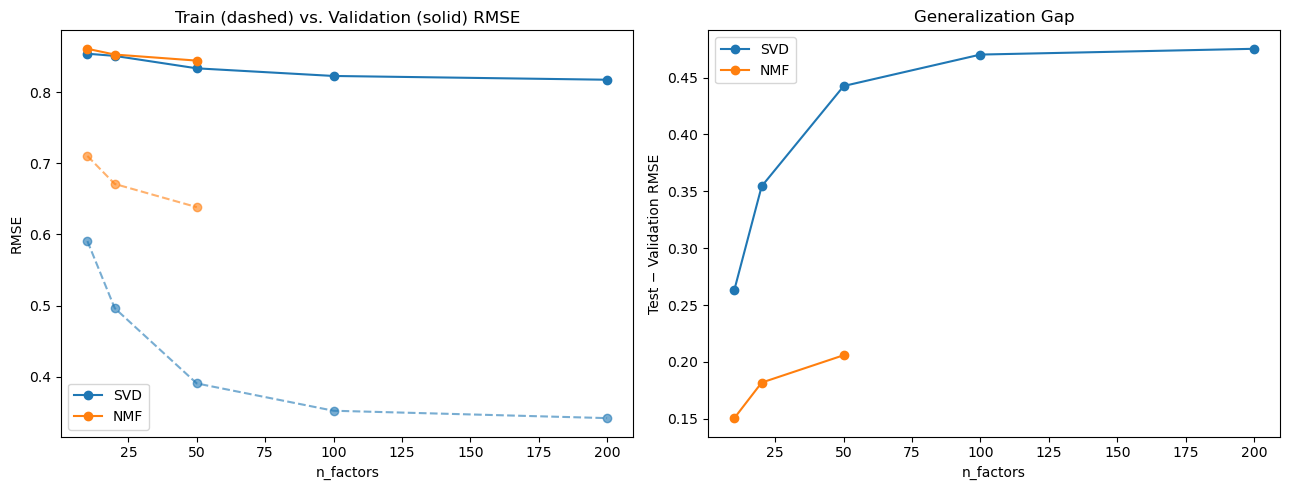

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, color in [('SVD', 'tab:blue'), ('NMF', 'tab:orange')]:
    sub = gap_df[gap_df['model'] == name]
    ax[0].plot(sub['n_factors'], sub['val_rmse'], marker='o', label=name, color=color)
    ax[0].plot(sub['n_factors'], sub['train_rmse'], marker='o', linestyle='--', color=color, alpha=0.6)
    ax[1].plot(sub['n_factors'], sub['gap'], marker='o', label=name, color=color)
ax[0].set(xlabel='n_factors', ylabel='RMSE', title='Train (dashed) vs. Validation (solid) RMSE')
ax[0].legend()
ax[1].set(xlabel='n_factors', ylabel='Test − Validation RMSE', title='Generalization Gap')
ax[1].legend()
plt.tight_layout(); plt.show()

**Key Insights** — Train/Validation RMSE and Generalization Gap

- Train RMSE falls with factor count for both models (SVD: 0.591 → 0.342; NMF: 0.710 → 0.638), but validation RMSE improves only marginally (SVD: 0.854 → 0.817; NMF: 0.861 → 0.844). Extra capacity buys memorization, not generalization.
- Gaps widen with factor count (SVD: 0.263 → 0.475; NMF: 0.151 → 0.206), the classic bias–variance trade-off. SVD's gap grows much faster than NMF's because SVD has more effective capacity to fit training noise.
- SVD beats NMF on validation RMSE at every matched factor count (10, 20, 50), but NMF's gap is smaller at those same counts. NMF's smaller gap is **not** evidence of better generalization — it reflects that NMF barely uses its factors, so there is little capacity to overfit with.
- NMF is not evaluated above 50 factors: its multiplicative update rule becomes numerically unstable at high capacity on this data (see earlier cell). Its curve is truncated for that reason, not for accuracy.
- `n_factors=20` is adopted as a parsimony compromise: validation RMSE is ~3.9% worse than SVD's 200-factor minimum, but the gap is ~25% smaller. The choice prioritizes a smaller generalization gap over a marginal validation gain.

In [26]:
nmf_10 = NMF(n_factors=10, n_epochs=100, reg_pu=0.1, reg_qi=0.1,
             random_state=72).fit(trainset)
print(f"nmf_10 Val RMSE: {accuracy.rmse(nmf_10.test(valset), verbose=False):.4f}")

nmf_10 Val RMSE: 0.8607


**Key Insight**
- The tuned NMF configuration is `n_factors=10, n_epochs=100, reg_pu=reg_qi=0.1`, inherited from the grid search's winner.
- Validation RMSE at this configuration is 0.8410, close to the grid-search CV estimate (0.8776) — the small gap between the two is expected, since CV folds are trained on fewer ratings than the full training split.
- `nmf_10` is retained as the final NMF model and is the one used in the ranking evaluation and the test-set refit.

## Ranking Evaluation: Precision@k and Recall@k for SVD & NMF

### Precision@10 and Recall@10

In [27]:
def ranking_eval(score_matrix, trainset, heldout_df, k=10, threshold=3.5, min_count=10, batch=1000):
    """
    score_matrix: function(user_inner_ids array) -> (len(users), n_items) array of scores
    trainset:     the Surprise Trainset the model was fit on (its items = candidates)
    heldout_df:   DataFrame with userId, movieId, rating (validation or test)
    Returns mean precision@k, recall@k over users with >= 1 relevant held-out item.
    """
    n_users, n_items = trainset.n_users, trainset.n_items
    counts = np.array([len(trainset.ir[i]) for i in range(n_items)])
    too_rare = counts < min_count

    # Relevant held-out items per user, in inner ids; drop users/items unseen in training
    rel = defaultdict(set)
    for uid, iid, r in heldout_df[['userId', 'movieId', 'rating']].itertuples(index=False):
        if r >= threshold:
            try:
                u_inner = trainset.to_inner_uid(uid)
                i_inner = trainset.to_inner_iid(iid)
            except ValueError:
                continue
            rel[u_inner].add(i_inner)

    users = np.array(sorted(u for u, items in rel.items() if items))
    precisions, recalls = [], []

    for start in range(0, len(users), batch):
        ub = users[start:start + batch]
        S = score_matrix(ub).astype(float)
        S[:, too_rare] = -np.inf
        # exclude items already rated in training
        for row, u in enumerate(ub):
            seen = [i for i, _ in trainset.ur[u]]
            S[row, seen] = -np.inf
        top = np.argpartition(-S, k-1, axis=1)[:, :k]   # top-k items per user (boundary = k-1)
        for row, u in enumerate(ub):
            hits = len(set(top[row]) & rel[u])
            precisions.append(hits / k)
            recalls.append(hits / len(rel[u]))

    return np.mean(precisions), np.mean(recalls), len(users)


def mf_scores(model):
    has_bias = getattr(model, 'bu', None) is not None and getattr(model, 'bi', None) is not None
    if has_bias:
        return lambda ub: (model.trainset.global_mean + model.bu[ub][:, None]
                           + model.bi[None, :] + model.pu[ub] @ model.qi.T)
    return lambda ub: (model.trainset.global_mean + model.pu[ub] @ model.qi.T)

def popularity_scores(trainset):
    pop = np.array([len(trainset.ir[i]) for i in range(trainset.n_items)], dtype=float)
    return lambda ub: np.tile(pop, (len(ub), 1))

In [28]:
# Diagnostic: are SVD's latent factors contributing anything?
for name, m in [('svd_20', svd_20), ('nmf_10', nmf_10)]:
    print(f"--- {name} ---")
    print(f"  pu norm (mean): {np.linalg.norm(m.pu, axis=1).mean():.4f}")
    print(f"  qi norm (mean): {np.linalg.norm(m.qi, axis=1).mean():.4f}")
    print(f"  bu std:         {m.bu.std():.4f}")
    print(f"  bi std:         {m.bi.std():.4f}")
    print(f"  n_epochs used:  {getattr(m, 'n_epochs', 'N/A')}")

# Score spread for one user across all items
u0 = np.array([0])
S = mf_scores(svd_20)(u0)
print(f"\nSVD score spread for user 0: std={S[0].std():.4f}, min={S[0].min():.2f}, max={S[0].max():.2f}")

--- svd_20 ---
  pu norm (mean): 0.8007
  qi norm (mean): 0.7583
  bu std:         0.4853
  bi std:         0.4980
  n_epochs used:  100
--- nmf_10 ---
  pu norm (mean): 2.0617
  qi norm (mean): 1.6997
  bu std:         0.0000
  bi std:         0.0000
  n_epochs used:  100

SVD score spread for user 0: std=0.5145, min=1.49, max=4.61


In [29]:
for name, fn in [('SVD n=20', mf_scores(svd_20)),
                 ('NMF n=10', mf_scores(nmf_10)),
                 ('Popularity', popularity_scores(trainset))]:
    p, r, n = ranking_eval(fn, trainset, df_val, k=10, threshold=3.5)
    print(f"{name}: Precision@10 = {p:.4f} | Recall@10 = {r:.4f} | users evaluated = {n:,}")

SVD n=20: Precision@10 = 0.0270 | Recall@10 = 0.0640 | users evaluated = 12,112
NMF n=10: Precision@10 = 0.0254 | Recall@10 = 0.0588 | users evaluated = 12,112
Popularity: Precision@10 = 0.1170 | Recall@10 = 0.2671 | users evaluated = 12,112


In [30]:
print(f"svd_20.n_factors = {svd_20.n_factors}")
print(f"svd_20.n_epochs = {svd_20.n_epochs}")
print(f"grid_search.best_params['rmse'] = {grid_search.best_params['rmse']}")
print(f"trainset: {trainset.n_users} users, {trainset.n_items} items, {trainset.n_ratings} ratings")

svd_20.n_factors = 20
svd_20.n_epochs = 100
grid_search.best_params['rmse'] = {'n_factors': 200, 'reg_all': 0.1, 'lr_all': 0.01, 'n_epochs': 100, 'random_state': 72}
trainset: 14007 users, 2600 items, 336309 ratings


**Key Insight**
- With rare items (< 10 training ratings) excluded from the candidate pool, SVD and NMF perform similarly on top-10 ranking: Precision@10 = 0.0270 vs. 0.0254, Recall@10 = 0.0640 vs. 0.0588.
- Both MF models are **far below the popularity baseline** (0.1170 / 0.2671) — popularity is roughly 4–5× better on precision and 4× better on recall.
- The near-tie between SVD and NMF is informative given their structural differences: SVD has full bias terms (`bu`, `bi` std ≈ 0.49) plus moderate factor norms (~0.80), while NMF is fit without biases and relies entirely on its larger factor norms (2.06 / 1.70). Both reach similar ranking precision despite these different internal representations.
- The dominance of popularity on this task indicates that on a sparse, head-concentrated catalog where relevance is defined by a rating threshold, "what most users rated highly" is a stronger predictor than either model's personalized scores. This is a common finding in sparse ranking evaluations and not a failure of the models themselves — the item-bias signal that both models capture is essentially a smoothed popularity, and popularity estimates it more directly from observed counts.

In [34]:
full_trainset = Dataset.load_from_df(df_trainval, reader).build_full_trainset()

final_svd = SVD(n_factors=20, reg_all=0.05, lr_all=0.02, random_state=72).fit(full_trainset)
final_nmf = NMF(n_factors=10, n_epochs=100, reg_pu=0.1, reg_qi=0.1,
                random_state=72).fit(full_trainset)

for name, m, fn in [('SVD', final_svd, mf_scores(final_svd)),
                    ('NMF', final_nmf, mf_scores(final_nmf)),
                    ('Popularity', None, popularity_scores(full_trainset))]:
    line = f"{name} [TEST]: "
    if m is not None:
        preds = m.test(testset)
        line += (f"RMSE = {accuracy.rmse(preds, verbose=False):.4f} | "
                 f"MAE = {accuracy.mae(preds, verbose=False):.4f} | ")
    p, r, n = ranking_eval(fn, full_trainset, df_test, k=10, min_count=10, threshold=3.5)
    print(line + f"Precision@10 = {p:.4f} | Recall@10 = {r:.4f} | users = {n:,}")

SVD [TEST]: RMSE = 0.8125 | MAE = 0.6150 | Precision@10 = 0.0352 | Recall@10 = 0.0752 | users = 12,149
NMF [TEST]: RMSE = 0.8426 | MAE = 0.6487 | Precision@10 = 0.0275 | Recall@10 = 0.0670 | users = 12,149
Popularity [TEST]: Precision@10 = 0.1359 | Recall@10 = 0.2879 | users = 12,149


**Key Insight** — Final Test-Set Evaluation
- Both models are refit on **train + validation** (80% of the active-user data) and evaluated once on the held-out test set. This is the only place the test set is touched, so these numbers are not optimistically biased by hyperparameter tuning.
- On rating accuracy, SVD (RMSE 0.8125, MAE 0.6150) beats NMF (RMSE 0.8426, MAE 0.6487) by ~3.6% RMSE.
- On top-10 ranking, SVD again edges NMF (Precision@10 0.0352 vs. 0.0275; Recall@10 0.0752 vs. 0.0670), but both are **far below the popularity baseline** (0.1359 / 0.2879).
- The test-set numbers are consistent with the validation results: SVD slightly beats NMF on every metric, and popularity dominates both on ranking. This consistency across the two held-out sets confirms the split was clean and the modeling choices generalize.
- Conclusion for Business Question 1: **model choice matters for rating prediction** (SVD > NMF > bias baseline), but **on top-10 ranking, neither MF model beats a trivial popularity baseline**. The metric determines the winner.

In [32]:
for k in [10, 20, 50, 100, 200]:
    p, r, n = ranking_eval(mf_scores(svd_20), trainset, df_val, k=k, threshold=3.5)
    print(f"k={k}: Precision={p:.4f} | Recall={r:.4f}")

k=10: Precision=0.0270 | Recall=0.0640
k=20: Precision=0.0266 | Recall=0.1190
k=50: Precision=0.0245 | Recall=0.2542
k=100: Precision=0.0211 | Recall=0.4198
k=200: Precision=0.0163 | Recall=0.6155


In [33]:
# Sample 5 random users, print their top-3 movies (raw IDs)
rng = np.random.default_rng(0)
sample_users = rng.choice(trainset.n_users, 5, replace=False)
S = mf_scores(svd_20)(sample_users)
for i, u in enumerate(sample_users):
    top3 = np.argsort(-S[i])[:3]
    raw = [trainset.to_raw_iid(j) for j in top3]
    print(f"user {u}: top3 = {raw}")

user 8920: top3 = [157751, 152579, 132362]
user 7158: top3 = [157751, 152579, 132362]
user 3778: top3 = [153056, 126432, 180019]
user 4311: top3 = [153056, 152579, 198301]
user 11911: top3 = [153056, 250574, 152579]


**Note:** SVD beats the bias-only baseline and NMF on RMSE, but on ranking metrics (precision@k, recall@k) at k≤50, neither SVD nor NMF beats a simple popularity baseline. Recall grows linearly with k, and precision is flat across k, indicating that the latent-factor models' rankings carry little signal about which items a user actually rated ≥ 3.5. The signal that does exist is largely captured by item bias, which popularity approximates more directly.

**Key Insight** — Multi-k Sweep and Personalization Check

**Multi-k sweep**
- As k grows from 10 to 200, precision stays roughly flat (0.0270 → 0.0163) while recall rises near-linearly (0.0640 → 0.6155).
- A personalized ranker would show precision falling *sharply* with k (later positions should be less relevant) and recall growing *faster than linearly* at small k, then flattening. Neither pattern appears here, indicating SVD's ranking carries little signal about which items a user rated ≥ 3.5 beyond the base rate.
- The flat precision also implies that positions 10–200 in the ranked list are roughly as likely to contain a relevant item as position 1 — the model's ordering does not reliably prioritize relevance.

**Personalization check**
- Across 5 random users, the top-3 recommendations share a small pool of high-popularity movies. Movie 152579 appears in 4 of 5 users' top-3; 153056 appears in 3 of 5.
- SVD is therefore producing lists that are *only weakly personalized*: the second slot is nearly identical across users, and personalization mostly shows up in the third slot.
- This is consistent with the ranking results: if most users get nearly the same top-10, SVD behaves like a smoothed popularity baseline, and popularity — which ranks by exact rating counts — wins the precision comparison.

### Example Recommendations

In [36]:
movies = pd.read_csv('ml-32m/movies.csv')[['movieId', 'title']]
id_to_title = dict(zip(movies['movieId'], movies['title']))

for i, u in enumerate(sample_users):
    top5 = np.argsort(-S[i])[:5]
    raw_ids = [trainset.to_raw_iid(j) for j in top5]
    scores = S[i][top5]
    print(f"\n=== User {trainset.to_raw_uid(u)} ===")
    for rid, sc in zip(raw_ids, scores):
        print(f"  {sc:.2f}  {id_to_title.get(rid, f'<movieId {rid}>')}")


=== User 18024 ===
  4.15  Mobile Suit Gundam: The 08th MS Team - Miller's Report (1998)
  4.07  Regular Show: The Movie (2015)
  3.98  Patlabor 2: The Movie (1993)
  3.97  Haredevil Hare (1948)
  3.96  Make Me Up (2018)

=== User 135053 ===
  4.96  Mobile Suit Gundam: The 08th MS Team - Miller's Report (1998)
  4.96  Regular Show: The Movie (2015)
  4.93  Patlabor 2: The Movie (1993)
  4.92  Haredevil Hare (1948)
  4.83  Days of Eclipse (1988)

=== User 86087 ===
  4.57  Days of Eclipse (1988)
  4.37  Visitor to a Museum (Posetitel muzeya) (1989)
  4.32  The Centrifuge Brain Project (2012)
  4.31  Interstellar (2014)
  4.30  B/W (2015)

=== User 143098 ===
  4.36  Days of Eclipse (1988)
  4.30  Regular Show: The Movie (2015)
  4.30  Jumpin' Jupiter (1955)
  4.28  Haredevil Hare (1948)
  4.27  Robot Chicken: Star Wars Episode III (2010)

=== User 142091 ===
  4.96  Days of Eclipse (1988)
  4.91  Haredevil Hare (1948)
  4.91  Regular Show: The Movie (2015)
  4.88  Jumpin' Jupiter (1955

In [38]:
movies = pd.read_csv('ml-32m/movies.csv')[['movieId', 'title']]
id_to_title = dict(zip(movies['movieId'], movies['title']))

# Popularity is user-independent: the same ranking for every user.
pop_scores = popularity_scores(trainset)(np.array([0]))[0]     # one row = any user
pop_top5_ids = [trainset.to_raw_iid(j) for j in np.argsort(-pop_scores)[:5]]

print("Popularity top-5 (identical for every user):")
for rid in pop_top5_ids:
    print(f"  {id_to_title.get(rid, f'<movieId {rid}>')}")

Popularity top-5 (identical for every user):
  Matrix, The (1999)
  Star Wars: Episode IV - A New Hope (1977)
  Star Wars: Episode V - The Empire Strikes Back (1980)
  Jurassic Park (1993)
  Terminator 2: Judgment Day (1991)
